# Code Demonstration

#### Necesarry Libraries

In [ ]:
# !pip install matplotlib numpy
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFilter
from IPython.display import display
import cv2
from ultralytics import YOLO
import os
import random
import PIL.ImageChops as ImageChops

## YOLO enemy detection

In [ ]:
# File paths to different assets
file_enemy = "enemy"
file_env = "environment"

In [24]:
def preprocess_frame(frame):
    # Convert frame from BGR (OpenCV default) to RGB
    frame_np = np.array(frame)
    frame_rgb = cv2.cvtColor(frame_np, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(frame_rgb)
    
    # First crop: according to processing code (assumed frame is 2560x1440)
    crop_box_1 = (0, 0, 2080, 1440)
    image_cropped = pil_image.crop(crop_box_1)
    
    # Second crop: crop equally from left and right to obtain a 1440x1440 square
    crop_box_2 = (320, 0, 320 + 1440, 1440)
    final_image = image_cropped.crop(crop_box_2)
    
    # Resize to 640x640 (model input size)
    img_resized = final_image.resize((640, 640))
    
    # Convert back to BGR numpy array for OpenCV
    processed_frame = cv2.cvtColor(np.array(img_resized), cv2.COLOR_RGB2BGR)
    return processed_frame

def apply_filter_2(image, param1):
    """
    Applies a Sobel edge detector.
    'param1' is used as the kernel size.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Compute gradients along the x and y axis, using kernel size (must be odd)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=param1)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=param1)
    sobel = cv2.magnitude(sobelx, sobely)
    # Normalize the result to 0-255 then convert back to uint8
    sobel = np.uint8(255 * sobel / np.max(sobel))
    return cv2.cvtColor(sobel, cv2.COLOR_GRAY2BGR)

def add_outline(img, thickness=1, outline_color=(0, 0, 0, 255)):
    """
    Adds a crisp black outline to a transparent image by dilating the alpha channel.
    Uses an expansion approach to ensure the outline sits around the enemy.

    Parameters:
      img: PIL.Image object in RGBA mode.
      thickness: outline thickness in pixels.
      outline_color: RGBA tuple for the outline color.

    Returns:
      A new PIL.Image with an outline added.
    """
    if thickness <= 0:
        return img

    # Ensure the image is in RGBA.
    img = img.convert("RGBA")

    # Create a new blank image to accommodate the outline
    new_size = (img.width + thickness * 2, img.height + thickness * 2)
    canvas = Image.new("RGBA", new_size, (0, 0, 0, 0))
    canvas.paste(img, (thickness, thickness))

    # Extract and dilate the alpha channel
    alpha = canvas.split()[-1]
    dilated = alpha.filter(ImageFilter.MaxFilter(thickness * 2 + 1))

    # The outline mask is the dilated alpha minus the original alpha
    outline_mask = ImageChops.subtract(dilated, alpha)

    # Create an image for the outline using the outline_color
    outline_img = Image.new("RGBA", new_size, (0, 0, 0, 0))
    outline_img.paste(outline_color, mask=outline_mask)

    # Composite the outline and the original image
    final_img = Image.alpha_composite(outline_img, canvas)
    return final_img


def boxes_overlap(box1, box2):
    return not (box1[2] <= box2[0] or box1[0] >= box2[2] or 
                box1[3] <= box2[1] or box1[1] >= box2[3])

def is_mostly_transparent(img, threshold=0.5):
    if img.mode != "RGBA":
        img = img.convert("RGBA")
    alpha = img.getchannel("A")
    pixels = list(alpha.getdata())
    transparent_count = sum(1 for px in pixels if px == 0)
    return (transparent_count / len(pixels)) > threshold

def crop_enemy(enemy_img):
    if random.random() < 0.3:  # 30% chance to crop
        direction = random.choice(["left", "right", "top", "bottom"])
        crop_ratio = random.uniform(0, 0.3)  # Crop between 0-30%
        width, height = enemy_img.size

        if direction == "left":
            enemy_img = enemy_img.crop((int(width * crop_ratio), 0, width, height))
        elif direction == "right":
            enemy_img = enemy_img.crop((0, 0, int(width * (1 - crop_ratio)), height))
        elif direction == "top":
            enemy_img = enemy_img.crop((0, int(height * crop_ratio), width, height))
        elif direction == "bottom":
            enemy_img = enemy_img.crop((0, 0, width, int(height * (1 - crop_ratio))))
    return enemy_img

def generate_yolo_sample(env_img_path, enemy_directory, output_directory=None, val_split=0.2):
    enemy_files = [f for f in os.listdir(enemy_directory) if f.endswith('.png')]
    if not enemy_files:
        print("No enemy images found.")
        return None, None

    # Open and preprocess environment image
    env_img = Image.open(env_img_path).convert("RGBA")
    env_np = preprocess_frame(env_img)
    env_rgb = cv2.cvtColor(env_np, cv2.COLOR_BGR2RGB)
    env_img = Image.fromarray(env_rgb)
    env_width, env_height = env_img.size

    restricted_areas = [
        (0, 0, 76, 144),    # Top-left restricted area
        (300, 287, 336, 326)
    ]

    annotations = []
    placed_boxes = []
    n_enemies = random.randint(1, 4)
    enemy_count = 0

    while enemy_count < n_enemies:
        enemy_file = random.choice(enemy_files)
        enemy_path = os.path.join(enemy_directory, enemy_file)
        enemy_img = Image.open(enemy_path).convert("RGBA")

        if is_mostly_transparent(enemy_img, 0.5):
            continue

        enemy_img = crop_enemy(enemy_img)
        enemy_img_resized = enemy_img.resize((enemy_img.width * 2, enemy_img.height * 2), resample=Image.BICUBIC)
        enemy_img_resized = add_outline(enemy_img_resized, thickness=1)
        enemy_img_resized = enemy_img_resized.resize((enemy_img_resized.width * 2, enemy_img_resized.height * 2), resample=Image.BOX)
        e_width, e_height = enemy_img_resized.size

        max_x = env_width - e_width
        max_y = env_height - e_height
        if max_x <= 0 or max_y <= 0:
            continue

        rand_x = random.randint(0, max_x)
        rand_y = random.randint(0, max_y)
        new_box = (rand_x, rand_y, rand_x + e_width, rand_y + e_height)

        if any(boxes_overlap(new_box, placed) for placed in placed_boxes):
            continue
        if any(boxes_overlap(new_box, restricted) for restricted in restricted_areas):
            continue

        env_img.paste(enemy_img_resized, (rand_x, rand_y), enemy_img_resized)
        placed_boxes.append(new_box)

        x_center = (rand_x + e_width / 2) / env_width
        y_center = (rand_y + e_height / 2) / env_height
        norm_width = e_width / env_width
        norm_height = e_height / env_height
        annotations.append(f"0 {x_center:.6f} {y_center:.6f} {norm_width:.6f} {norm_height:.6f}")

        enemy_count += 1

    # Apply Sobel filtering
    env_img_rgb = env_img.convert("RGB")
    env_np = np.array(env_img_rgb)
    env_cv = cv2.cvtColor(env_np, cv2.COLOR_RGB2BGR)
    filtered_env_cv = apply_filter_2(env_cv, param1=3)
    filtered_env_rgb = cv2.cvtColor(filtered_env_cv, cv2.COLOR_BGR2RGB)
    filtered_env_pil = Image.fromarray(filtered_env_rgb)

    # Optionally save output if output_directory is provided
    if output_directory:
        output_subdir = os.path.join(output_directory, 'val')
        os.makedirs(output_subdir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(env_img_path))[0]
        output_img_path = os.path.join(output_subdir, base_filename + '.png')

        filtered_env_pil.save(output_img_path)

        annotation_path = output_img_path.replace('.png', '.txt')
        with open(annotation_path, 'w') as f:
            f.write("\n".join(annotations))

    return filtered_env_pil, annotations

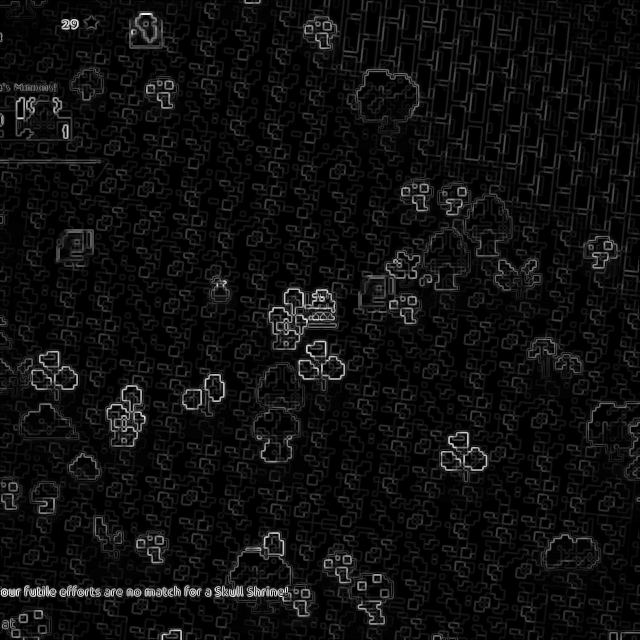

0 0.589063 0.459375 0.056250 0.056250
0 0.228125 0.046875 0.050000 0.056250
0 0.117188 0.387500 0.056250 0.056250

0: 640x640 3 enemys, 107.1ms
Speed: 5.6ms preprocess, 107.1ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)


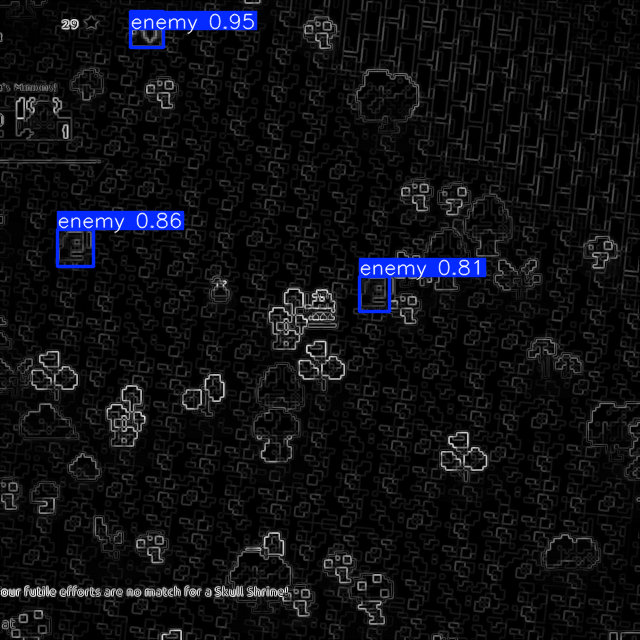

In [29]:
filtered_img, annotations = generate_yolo_sample(
    env_img_path="example_image.png",
    enemy_directory="example_enemies"
)

display(filtered_img)
print("\n".join(annotations))

# Load a model
model = YOLO("knut_sandbox/runs/detect/train/weights/best.pt")

results = model(filtered_img, conf=0.6)  

annotated_bgr = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
display(Image.fromarray(annotated_rgb))



## Skage

## Projectile Prediction
This sections shows how the projectile predictor can be used to predict future positions given a history.

In [2]:
from projectile_prediction.predictor_new import predict_future

In [3]:
# Version 1: Horizontal Straight Line
def generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0)):
    """Generate position at time t for straight-line movement"""
    x = start_pos[0] + velocity[0] * t
    y = start_pos[1] + velocity[1] * t
    return (x, y)

# Version 2: Angled Straight Line
def generate_straight_trajectory_v2(t, start_pos=(0, 0), velocity=(30, 30)):
    """Generate position at time t for straight-line movement at 45 degrees"""
    x = start_pos[0] + velocity[0] * t
    y = start_pos[1] + velocity[1] * t
    return (x, y)

# Circle Trajectory
def generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=1.0, phase=0):
    """Generate position at time t for circular movement"""
    angle = angular_speed * t + phase
    x = center[0] + radius * np.cos(angle)
    y = center[1] + radius * np.sin(angle)
    return (x, y)

# Version 1: Horizontal Sine Wave
def generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2, phase=0):
    """Generate position at time t for sinusoidal movement (horizontal)"""
    x = start_pos[0] + x_velocity * t
    # Simple sine wave based on x position (adjust divisor as needed for wavelength)
    # The divisor controls how many spatial units correspond to one cycle
    y = start_pos[1] + amplitude * np.sin(2 * np.pi * frequency * x / (x_velocity * 1.5) + phase) 
    return (x, y)

# Version 2: Angled Sine Wave
def generate_sine_trajectory_v2(t, start_pos=(0, 0), angle_deg=-45, speed=40, amplitude=50, frequency=2, phase=0):
    """Generate position at time t for sinusoidal movement at an angle"""
    angle_rad = np.radians(angle_deg)
    base_x = start_pos[0] + speed * t * np.cos(angle_rad)
    base_y = start_pos[1] + speed * t * np.sin(angle_rad)
    perp_angle = angle_rad + np.pi/2
    x = base_x + amplitude * np.sin(2 * np.pi * frequency * t + phase) * np.cos(perp_angle)
    y = base_y + amplitude * np.sin(2 * np.pi * frequency * t + phase) * np.sin(perp_angle)
    return (x, y)

def add_noise(positions, noise_level=2.0):
    """Add Gaussian noise to a list of positions"""
    noisy_positions = []
    for pos in positions:
        noise_x = np.random.normal(0, noise_level)
        noise_y = np.random.normal(0, noise_level)
        noisy_positions.append((pos[0] + noise_x, pos[1] + noise_y))
    return noisy_positions

Simple function for simulating, predicting, and plotting.

In [4]:
def run_and_plot_simulation(dt, n_steps, future_steps, noise_level, trajectory_generators, figure_title, seed=0):
    num_plots = len(trajectory_generators)
    fig, axes = plt.subplots(num_plots, 1, figsize=(8, 4 * num_plots))
    fig.suptitle(figure_title, fontsize=16)

    for i, (name, trajectory_func) in enumerate(trajectory_generators):
        ax = axes[i]
        print(f"Processing: {name}")

        # Generate trajectory data
        total_steps = n_steps + future_steps
        all_times = np.arange(0, total_steps * dt, dt)
        # Ensure enough points are generated
        if len(all_times) < total_steps:
             all_times = np.arange(0, (total_steps + 1) * dt, dt)[:total_steps]

        all_positions = [trajectory_func(t) for t in all_times]

        history_times = all_times[:n_steps]
        history_pos_clean = all_positions[:n_steps]
        actual_future_times = all_times[n_steps:total_steps]
        actual_future_pos = all_positions[n_steps:total_steps]

        # Add noise
        current_noise = noise_level
        # Specific noise adjustment for horizontal straight line example
        if name == "Straight (Horizontal)": 
            # Less noise for straight line, this is just done because the straight line is really sensitive to the noise because of the short distance it travels in the examples.
            current_noise = noise_level / 3 if noise_level > 0 else 0 
            ax.set_ylim(-10, 10) # Zoom in for straight line

        history_pos_noisy = add_noise(history_pos_clean, current_noise)

        # Prepare history for predictor
        time_position_history = [[t, pos[0], pos[1]] for t, pos in zip(history_times, history_pos_noisy)]

        # Predict future
        predicted_future = predict_future(
            time_position_history, 
            future_times=actual_future_times,
            num_points=future_steps
        )

        # Convert to numpy arrays for plotting
        history_np_clean = np.array(history_pos_clean)
        history_np_noisy = np.array(history_pos_noisy)
        actual_future_np = np.array(actual_future_pos)
        # Ensure predicted_future is not empty before converting
        predicted_future_np = np.array(predicted_future) if predicted_future else np.empty((0,2))

        # --- Plotting ---
        # Plot actual future
        if actual_future_np.shape[0] > 0:
             ax.plot(actual_future_np[:, 0], actual_future_np[:, 1], 'g-', label="Actual Future", linewidth=2)
        
        # Plot predicted future if available
        if predicted_future_np.shape[0] > 0:
            ax.plot(predicted_future_np[:, 0], predicted_future_np[:, 1], 'r--', label="Predicted Future", linewidth=2)

        # Plot noisy history (input)
        if history_np_noisy.shape[0] > 0:
             ax.plot(history_np_noisy[:, 0], history_np_noisy[:, 1], 'bo', markersize=4, label="Noisy Input Points")
        
        # Add titles and labels
        ax.set_title(f"{name} - Noise σ: {current_noise:.2f} px")
        ax.set_xlabel("x position (pixels)")
        ax.set_ylabel("y position (pixels)")
        ax.legend()
        ax.grid(True)
        
        # Set aspect ratio for circle or rotated plots
        if "Circle" in name or "°" in name: # Adjust condition if needed
            ax.set_aspect('equal', adjustable='datalim')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

#### Simulated Conditions - No Noise

Processing: Straight (Horizontal)
Model errors - Straight: 0.00, Circle: 34395.06, Sine: 0.00
Sine model selected but amplitude (0.00) below threshold (1.0).
Defaulting to straight line model instead.
Best model: straight
Processing: Circle
Model errors - Straight: 17201.47, Circle: 0.00, Sine: 1089.91
Best model: circle
Processing: Sine (Horizontal)
Model errors - Straight: 23738.65, Circle: 19663.19, Sine: 0.00
Sine model selected with amplitude: 50.00
Best model: sine


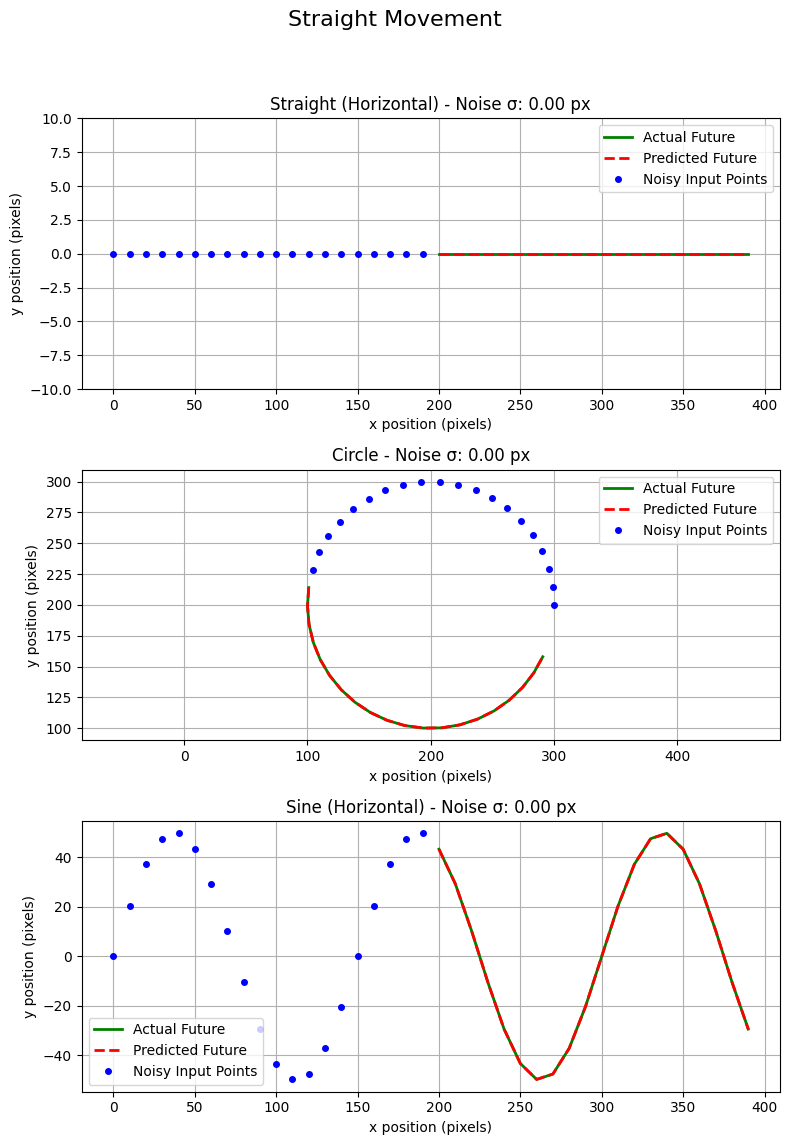

In [5]:
# Simulation parameters
dt_example = 0.05
n_steps_example = 20
future_steps_example = 20
noise_level_example = 0.0 # Example: No noise

# Trajectory generators 
trajectory_generators_example = [
    ("Straight (Horizontal)", lambda t: generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0))),
    ("Circle", lambda t: generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=3.0)),
    ("Sine (Horizontal)", lambda t: generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2))
]

# Title for the plot
figure_title_example = 'Straight Movement'

# Call the function
run_and_plot_simulation(
    dt=dt_example,
    n_steps=n_steps_example,
    future_steps=future_steps_example,
    noise_level=noise_level_example,
    trajectory_generators=trajectory_generators_example,
    figure_title=figure_title_example
)

#### Rotated with no noise, just to show that it works with movement that does not just go horizonatally

Processing: Straight (45°)
Model errors - Straight: 0.00, Circle: 12440.94, Sine: 0.00
Sine model selected but amplitude (0.00) below threshold (1.0).
Defaulting to straight line model instead.
Best model: straight
Processing: Circle
Model errors - Straight: 22193.17, Circle: 0.00, Sine: 22195.33
Best model: circle
Processing: Sine (-45°)
Model errors - Straight: 48222.86, Circle: 86483.31, Sine: 0.00
Sine model selected with amplitude: 50.00
Best model: sine


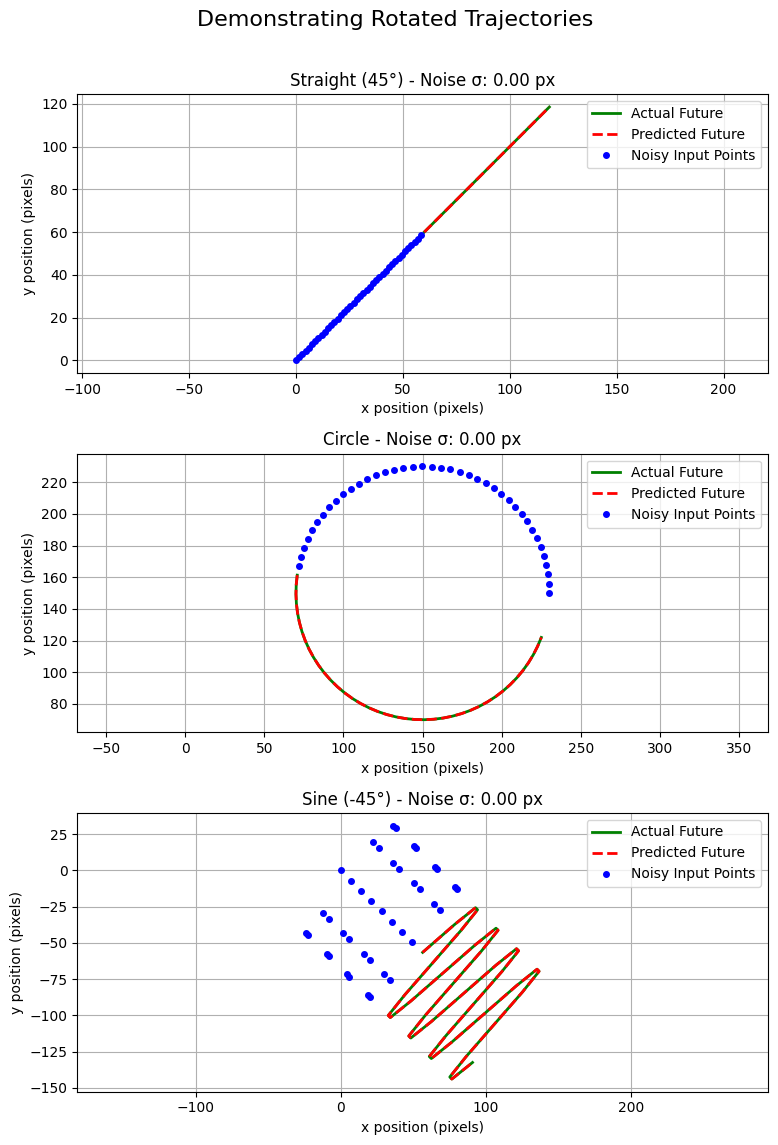

In [6]:
dt_v2 = 0.05
n_steps_v2 = 40
future_steps_v2 = 40
noise_level_v2 = 0.0

trajectory_generators_v2 = [
    ("Straight (45°)", lambda t: generate_straight_trajectory_v2(t, start_pos=(0, 0), velocity=(30, 30))),
    # Using different circle parameters for variety
    ("Circle", lambda t: generate_circle_trajectory(t, center=(150, 150), radius=80, angular_speed=1.5)), 
    ("Sine (-45°)", lambda t: generate_sine_trajectory_v2(t, start_pos=(0, 0), angle_deg=-45, speed=40, amplitude=50, frequency=2))
]

# Create figure
fig2, axes2 = plt.subplots(len(trajectory_generators_v2), 1, figsize=(8, 12))
fig2.suptitle('Demonstrating Rotated Trajectories', fontsize=16)

np.random.seed(0)

for i, (name, trajectory_func) in enumerate(trajectory_generators_v2):
    ax = axes2[i]
    print(f"Processing: {name}")

    # Generate trajectory data
    total_steps = n_steps_v2 + future_steps_v2
    all_times = np.arange(0, total_steps * dt_v2, dt_v2)
    all_positions = [trajectory_func(t) for t in all_times]

    history_times = all_times[:n_steps_v2]
    history_pos_clean = all_positions[:n_steps_v2]
    actual_future_times = all_times[n_steps_v2:total_steps]
    actual_future_pos = all_positions[n_steps_v2:total_steps]

    # Add noise
    current_noise = noise_level_v2
    if "Straight" in name:
        # Less noise for straight line, this is just done because the straight line is really sensitive to the noise because of the short distance is traveles in the examples.
        current_noise = noise_level_v2 / 3 
    history_pos_noisy = add_noise(history_pos_clean, current_noise)

    # Prepare history for predictor
    time_position_history = [[t, pos[0], pos[1]] for t, pos in zip(history_times, history_pos_noisy)]

    # Predict future
    predicted_future = predict_future(
        time_position_history, 
        future_times=actual_future_times,
        num_points=future_steps_v2
    )

    # Convert to numpy arrays for plotting
    history_np_clean = np.array(history_pos_clean)
    history_np_noisy = np.array(history_pos_noisy)
    actual_future_np = np.array(actual_future_pos)
    # Ensure predicted_future is not empty before converting
    predicted_future_np = np.array(predicted_future) if predicted_future else np.empty((0,2))

    # --- Plotting ---
    # Plot actual future (ground truth)
    ax.plot(actual_future_np[:, 0], actual_future_np[:, 1], 'g-', label="Actual Future", linewidth=2)
    
    # Plot predicted future if available
    if predicted_future_np.shape[0] > 0:
        ax.plot(predicted_future_np[:, 0], predicted_future_np[:, 1], 'r--', label="Predicted Future", linewidth=2)
    
    # Plot clean history (faded)
    # ax.plot(history_np_clean[:, 0], history_np_clean[:, 1], 'c.', alpha=0.5, label="True Historical Path")
    
    # Plot noisy history (input)
    ax.plot(history_np_noisy[:, 0], history_np_noisy[:, 1], 'bo', markersize=4, label="Noisy Input Points")

    ax.set_title(f"{name} - Noise σ: {current_noise:.2f} px")
    ax.set_xlabel("x position (pixels)")
    ax.set_ylabel("y position (pixels)")
    ax.legend()
    ax.grid(True)
    
    ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

#### With some noise added to the data

Processing: Straight (Horizontal)
Model errors - Straight: 39.52, Circle: 1158.58, Sine: 31.56
Sine model selected but amplitude (0.86) below threshold (1.0).
Defaulting to straight line model instead.
Best model: straight
Processing: Circle
Model errors - Straight: 17119.09, Circle: 241.93, Sine: 1477.64
Best model: circle
Processing: Sine (Horizontal)
Model errors - Straight: 24424.71, Circle: 20928.74, Sine: 327.83
Sine model selected with amplitude: 50.52
Best model: sine


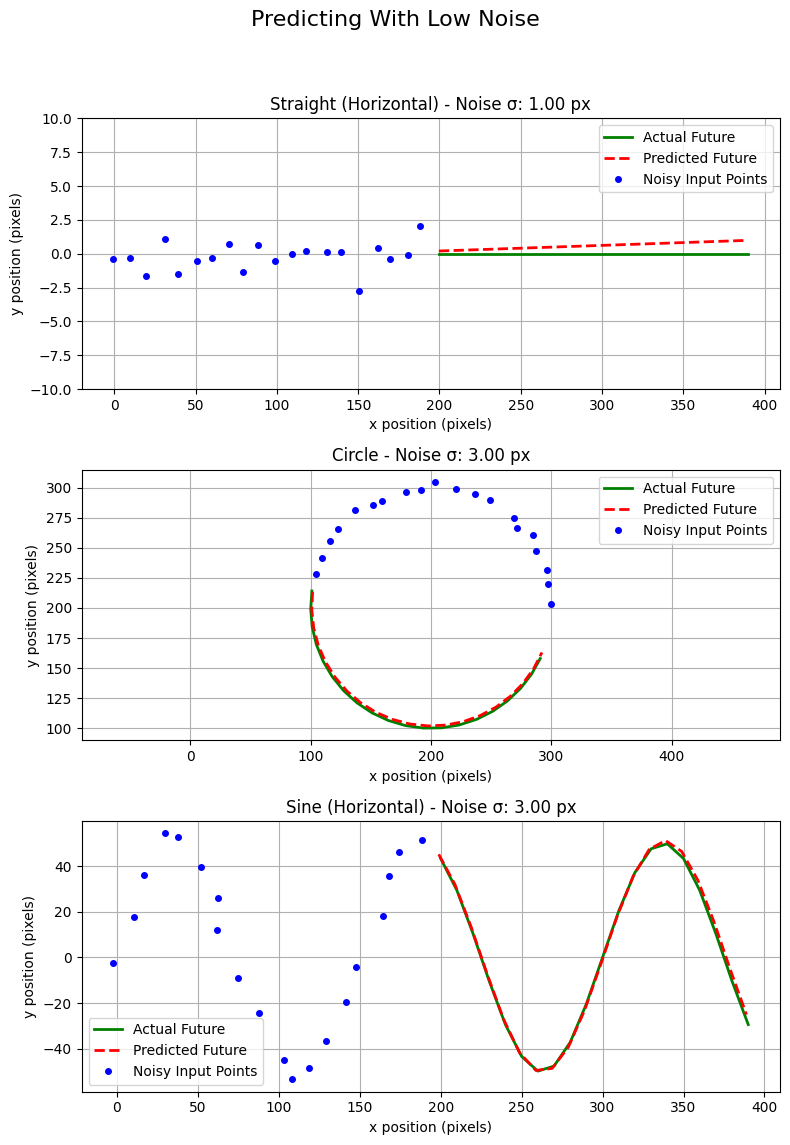

In [7]:
# Simulation parameters
dt_example = 0.05
n_steps_example = 20
future_steps_example = 20
noise_level_example = 3.0

# Trajectory generators 
trajectory_generators_example = [
    ("Straight (Horizontal)", lambda t: generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0))),
    ("Circle", lambda t: generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=3.0)),
    ("Sine (Horizontal)", lambda t: generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2))
]

# Title for the plot
figure_title_example = 'Predicting With Low Noise'

# Call the function
run_and_plot_simulation(
    dt=dt_example,
    n_steps=n_steps_example,
    future_steps=future_steps_example,
    noise_level=noise_level_example,
    trajectory_generators=trajectory_generators_example,
    figure_title=figure_title_example
)

#### With allot of noise

Processing: Straight (Horizontal)
Model errors - Straight: 115.56, Circle: 7430.57, Sine: 93.01
Sine model selected with amplitude: 1.58
Best model: sine
Processing: Circle
Model errors - Straight: 18281.92, Circle: 613.50, Sine: 1782.48
Best model: circle
Processing: Sine (Horizontal)
Model errors - Straight: 23630.98, Circle: 19775.82, Sine: 617.54
Sine model selected with amplitude: 49.20
Best model: sine


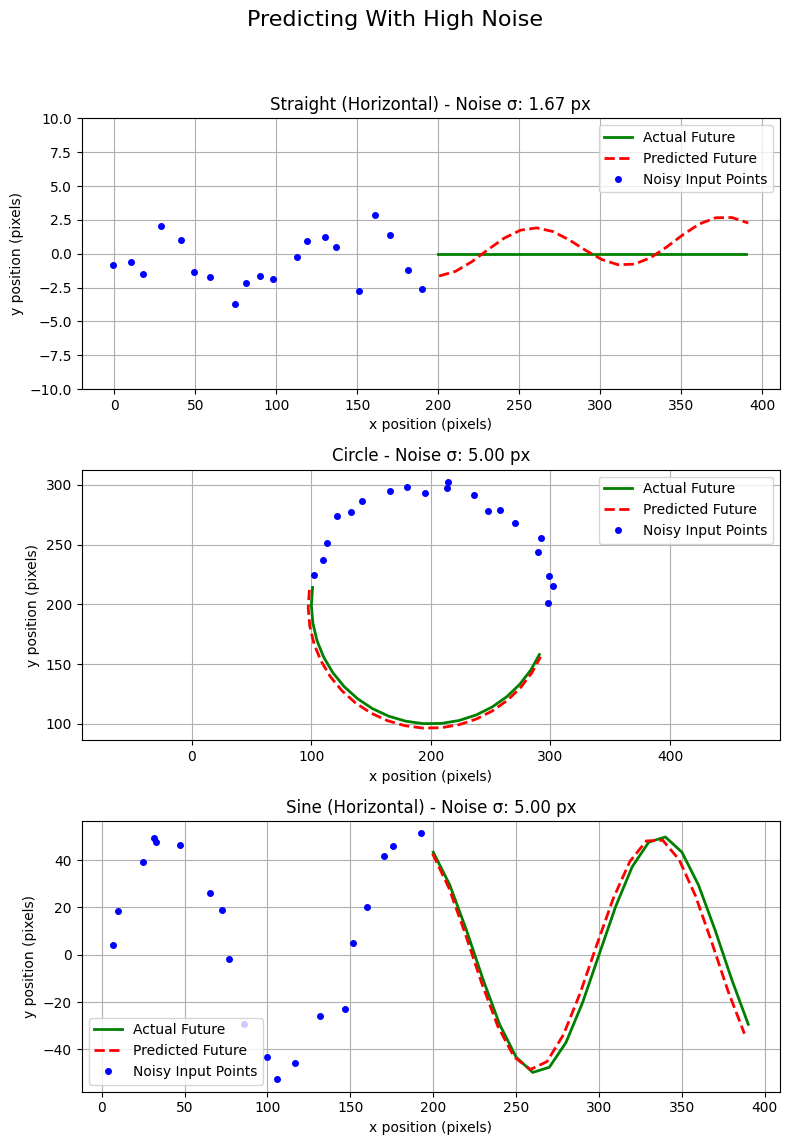

In [11]:
# Simulation parameters
dt_example = 0.05
n_steps_example = 20
future_steps_example = 20
noise_level_example = 5

# Trajectory generators 
trajectory_generators_example = [
    ("Straight (Horizontal)", lambda t: generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0))),
    ("Circle", lambda t: generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=3.0)),
    ("Sine (Horizontal)", lambda t: generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2))
]

# Title for the plot
figure_title_example = 'Predicting With High Noise'

# Call the function
run_and_plot_simulation(
    dt=dt_example,
    n_steps=n_steps_example,
    future_steps=future_steps_example,
    noise_level=noise_level_example,
    trajectory_generators=trajectory_generators_example,
    figure_title=figure_title_example,
    seed=1
)